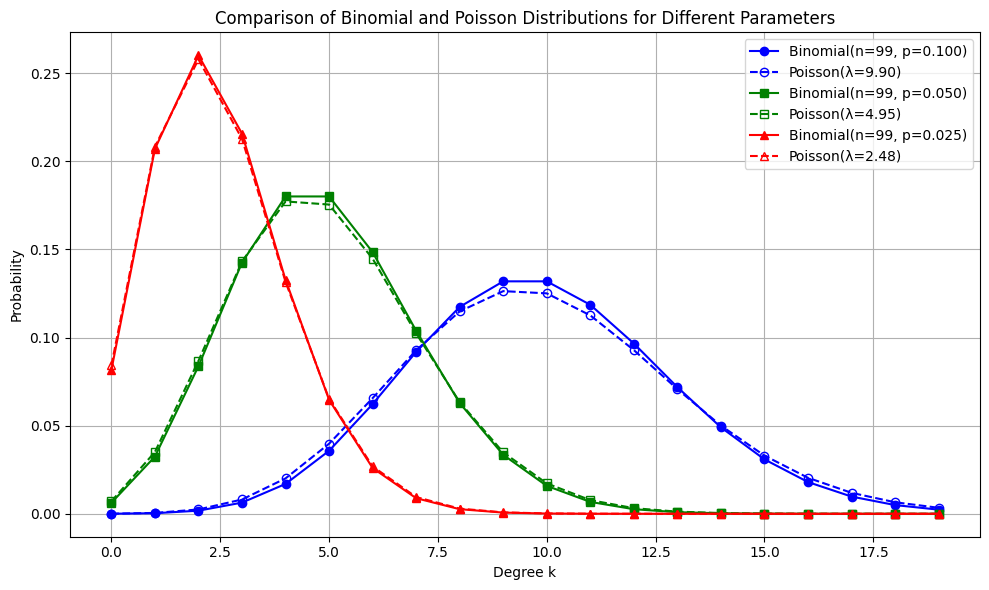

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, poisson
import random
import networkx as nx

np.random.seed(42)
random.seed(42)

params = [
    (100, 0.1),   
    (100, 0.05), 
    (100, 0.025) 
]

k = np.arange(0, 20)

plt.figure(figsize=(10, 6))

colors = ['blue', 'green', 'red']
markers = ['o', 's', '^']

for i, (n, p) in enumerate(params):
    lam = (n - 1) * p
    binom_pmf = binom.pmf(k, n-1, p)
    poisson_pmf = poisson.pmf(k, lam)
    
    plt.plot(k, binom_pmf, color=colors[i], marker=markers[i], linestyle='-', label=f'Binomial(n={n-1}, p={p:.3f})')
    plt.plot(k, poisson_pmf, color=colors[i], marker=markers[i], linestyle='--', fillstyle='none', label=f'Poisson(λ={lam:.2f})')

plt.title('Comparison of Binomial and Poisson Distributions for Different Parameters')
plt.xlabel('Degree k')
plt.ylabel('Probability')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



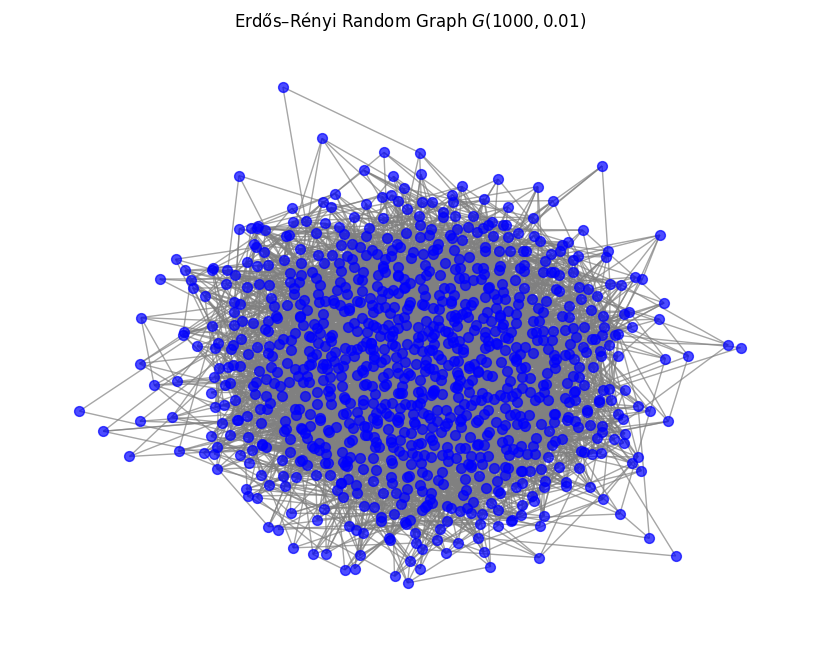

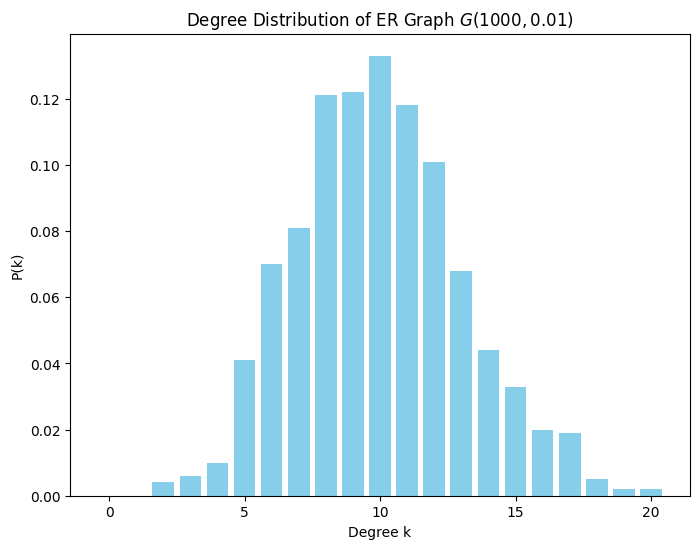

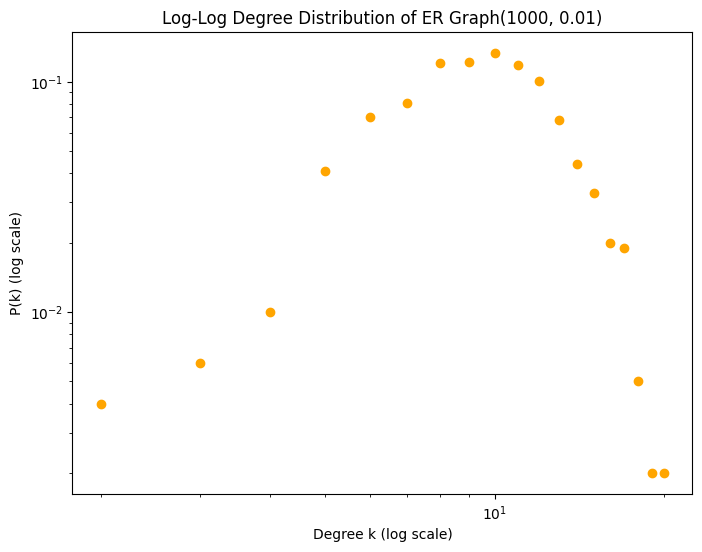

In [ ]:

n = 1000     
p = 0.01     

G = nx.erdos_renyi_graph(n, p)

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G) 
nx.draw(G, pos, node_size=50, node_color='blue', edge_color='gray', alpha=0.7)
plt.title(f"Erdős–Rényi Random Graph $G({n}, {p})$")
plt.show()

degrees = [deg for _, deg in G.degree()]

max_degree = max(degrees)
degree_counts = np.bincount(degrees, minlength=max_degree+1)
degree_prob = degree_counts / n  

degree_values = np.arange(len(degree_prob))

plt.figure(figsize=(8, 6))
plt.bar(degree_values, degree_prob, color='skyblue')
plt.xlabel('Degree k')
plt.ylabel('P(k)')
plt.title(f'Degree Distribution of ER Graph $G({n},{p})$')
plt.show()

nonzero = degree_prob > 0
plt.figure(figsize=(8, 6))
plt.loglog(degree_values[nonzero], degree_prob[nonzero], marker='o', linestyle='None', color='orange')
plt.xlabel('Degree k (log scale)')
plt.ylabel('P(k) (log scale)')
plt.title('Log-Log Degree Distribution of ER Graph(1000, 0.01)')
plt.show()
